Départ x0=-2 -> Minimum trouvé à x=-1.019 en 71 itérations
Départ x0=6 -> Minimum trouvé à x=4.810 en 160 itérations
Départ x0=2.2 -> Minimum trouvé à x=-1.018 en 267 itérations
Départ x0=2.3 -> Minimum trouvé à x=4.806 en 317 itérations


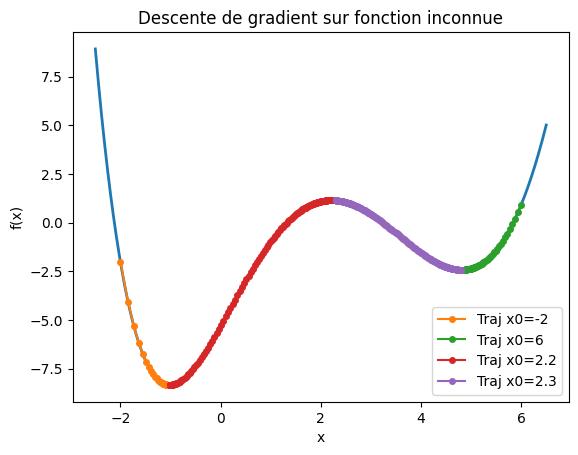

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# Partie C : Descente de gradient sur des données chargées
data = scipy.io.loadmat('data.mat')
x = data['x'].flatten()
f = data['f'].flatten()

xk = 2.2  # Initialisation
plt.figure(4)
plt.plot(x, f, linewidth=2)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")

df_data = np.gradient(f, x)
lam = 0.01
epsilon = 0.01
start_points = [-2, 6, 2.2, 2.3]

for x0 in start_points:
    xk = x0
    iterations = 0
    path_x = [xk]
    path_y = [] # On stockera les f(xk) pour l'affichage
    
    # On cherche la valeur f(x0) initiale (approximative)
    idx_init = (np.abs(x - xk)).argmin()
    path_y.append(f[idx_init])

    while True:
        # 1. Trouver l'index du point de données le plus proche de xk
        idx = (np.abs(x - xk)).argmin()
        
        # 2. Récupérer la dérivée et la valeur en ce point
        grad = df_data[idx]
        val = f[idx]
        
        # Condition d'arrêt
        if abs(grad) < epsilon or iterations > 1000:
            break
            
        # 3. Mise à jour (Descente de gradient)
        xk = xk - lam * grad
        iterations += 1
        
        # Stockage pour affichage
        path_x.append(xk)
        # On prend la valeur f correspondant au nouvel index proche
        idx_new = (np.abs(x - xk)).argmin()
        path_y.append(f[idx_new])

    # Affichage du résultat pour ce point de départ
    print(f"Départ x0={x0} -> Minimum trouvé à x={xk:.3f} en {iterations} itérations")
    plt.plot(path_x, path_y, 'o-', markersize=4, label=f'Traj x0={x0}')

plt.title("Descente de gradient sur fonction inconnue")
plt.legend()
plt.grid()
plt.show()